In [3]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt

from tqdm import tqdm

In [4]:
direc = r'C:\Users\Admin\Downloads\archive (8)\_dataset'

In [5]:
images = []
masks = []

for file in sorted(os.listdir(direc)):

    if file.endswith("_t.png"):
        images.append(file)

    elif file.endswith("_i2.png"):
        masks.append(file)

print("Images:", len(images))
print("Masks :", len(masks))

Images: 5000
Masks : 5000


In [6]:
images = sorted(images)
masks = sorted(masks)

for i in range(5):
    print(images[i], "<-->", masks[i])

0001_t.png <--> 0001_i2.png
0002_t.png <--> 0002_i2.png
0003_t.png <--> 0003_i2.png
0004_t.png <--> 0004_i2.png
0005_t.png <--> 0005_i2.png


In [7]:
IMG_SIZE = 128

X = []
Y = []

for i in tqdm(range(len(images))):

    image_path = os.path.join(direc, images[i])
    mask_path = os.path.join(direc, masks[i])

    image = cv2.imread(image_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Resize
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    X.append(image)
    Y.append(mask)

100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:32<00:00, 53.91it/s]


In [8]:
X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

print("Images:", X.shape)
print("Masks :", Y.shape)

Images: (5000, 128, 128, 3)
Masks : (5000, 128, 128)


In [9]:
X = X / 255.0

In [10]:
Y = Y / 255.0

In [11]:
Y = (Y > 0.5).astype(np.float32)

In [12]:
Y = np.expand_dims(Y, axis=-1)

print("Images:", X.shape)
print("Masks :", Y.shape)

Images: (5000, 128, 128, 3)
Masks : (5000, 128, 128, 1)


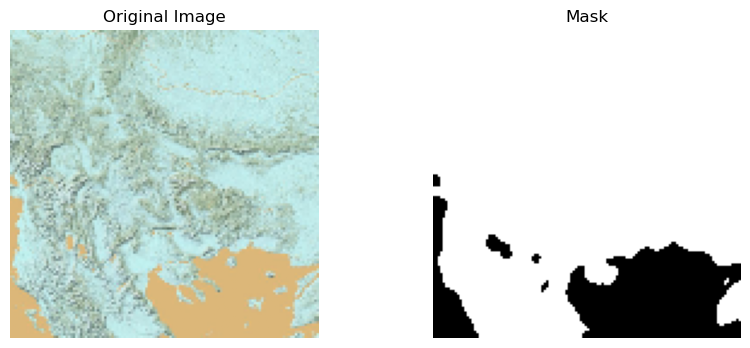

In [13]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(X[10])
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(Y[10].squeeze(), cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("Training images :", X_train.shape)
print("Validation images:", X_val.shape)

print("Training masks :", Y_train.shape)
print("Validation masks:", Y_val.shape)

Training images : (4000, 128, 128, 3)
Validation images: (1000, 128, 128, 3)
Training masks : (4000, 128, 128, 1)
Validation masks: (1000, 128, 128, 1)


In [16]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [17]:
tf.config.set_visible_devices([], 'GPU')

In [18]:
def build_unet():

    inputs = tf.keras.Input(shape=(128, 128, 3))

    # -------------------------
    # Encoder
    # -------------------------

    c1 = tf.keras.layers.Conv2D(
        16, 3, activation="relu", padding="same"
    )(inputs)

    c1 = tf.keras.layers.Conv2D(
        16, 3, activation="relu", padding="same"
    )(c1)

    p1 = tf.keras.layers.MaxPooling2D()(c1)


    c2 = tf.keras.layers.Conv2D(
        32, 3, activation="relu", padding="same"
    )(p1)

    c2 = tf.keras.layers.Conv2D(
        32, 3, activation="relu", padding="same"
    )(c2)

    p2 = tf.keras.layers.MaxPooling2D()(c2)


    c3 = tf.keras.layers.Conv2D(
        64, 3, activation="relu", padding="same"
    )(p2)

    c3 = tf.keras.layers.Conv2D(
        64, 3, activation="relu", padding="same"
    )(c3)

    p3 = tf.keras.layers.MaxPooling2D()(c3)


    # -------------------------
    # Bottleneck
    # -------------------------

    c4 = tf.keras.layers.Conv2D(
        128, 3, activation="relu", padding="same"
    )(p3)

    c4 = tf.keras.layers.Conv2D(
        128, 3, activation="relu", padding="same"
    )(c4)


    # -------------------------
    # Decoder
    # -------------------------

    u5 = tf.keras.layers.UpSampling2D()(c4)

    u5 = tf.keras.layers.Concatenate()([
        u5,
        c3
    ])

    c5 = tf.keras.layers.Conv2D(
        64, 3, activation="relu", padding="same"
    )(u5)

    c5 = tf.keras.layers.Conv2D(
        64, 3, activation="relu", padding="same"
    )(c5)


    u6 = tf.keras.layers.UpSampling2D()(c5)

    u6 = tf.keras.layers.Concatenate()([
        u6,
        c2
    ])

    c6 = tf.keras.layers.Conv2D(
        32, 3, activation="relu", padding="same"
    )(u6)

    c6 = tf.keras.layers.Conv2D(
        32, 3, activation="relu", padding="same"
    )(c6)


    u7 = tf.keras.layers.UpSampling2D()(c6)

    u7 = tf.keras.layers.Concatenate()([
        u7,
        c1
    ])

    c7 = tf.keras.layers.Conv2D(
        16, 3, activation="relu", padding="same"
    )(u7)

    c7 = tf.keras.layers.Conv2D(
        16, 3, activation="relu", padding="same"
    )(c7)


    # -------------------------
    # Output
    # -------------------------

    outputs = tf.keras.layers.Conv2D(
        1,
        1,
        activation="sigmoid"
    )(c7)


    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs
    )

    return model

In [19]:
model = build_unet()

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 128, 128, 16)      │             448 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 128, 128, 16)      │           2,320 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 64, 64, 16)        │               0 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 64, 64, 32)        │           4,640 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 64, 64, 32)        │           9,248 │ conv2d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 32, 32, 32)        │               0 │ conv2d_3[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 32, 32, 64)        │          18,496 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 32, 32, 64)        │          36,928 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 16, 16, 64)        │               0 │ conv2d_5[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 16, 16, 128)       │          73,856 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 16, 16, 128)       │         147,584 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d (UpSampling2D)  │ (None, 32, 32, 128)       │               0 │ conv2d_7[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 32, 32, 192)       │               0 │ up_sampling2d[0][0],       │
│                               │                           │                 │ conv2d_5[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_8 (Conv2D)             │ (None, 32, 32, 64)        │         110,656 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_9 (Conv2D)             │ (None, 32, 32, 64)        │          36,92

 Total params: 487,297 (1.86 MB)

 Trainable params: 487,297 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
def dice_score(y_true, y_pred):

    smooth = 1e-6

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_pred = tf.cast(
        y_pred > 0.5,
        tf.float32
    )

    intersection = tf.reduce_sum(
        y_true * y_pred
    )

    dice = (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true)
        +
        tf.reduce_sum(y_pred)
        +
        smooth
    )

    return dice

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        dice_score,
        "accuracy"
    ]
)

In [22]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_score",
        patience=4,
        mode="max",
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_score",
        factor=0.5,
        patience=2,
        mode="max",
        min_lr=0.00001
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_segmentation_model.keras",
        monitor="val_dice_score",
        mode="max",
        save_best_only=True
    )
]

In [23]:
history = model.fit(

    X_train,
    Y_train,

    validation_data=(
        X_val,
        Y_val
    ),

    epochs=20,

    batch_size=4,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 319s 299ms/step - accuracy: 0.9781 - dice_score: 0.9844 - loss: 0.0541 - val_accuracy: 0.9922 - val_dice_score: 0.9939 - val_loss: 0.0202 - learning_rate: 0.0010
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 395s 372ms/step - accuracy: 0.9924 - dice_score: 0.9939 - loss: 0.0198 - val_accuracy: 0.9925 - val_dice_score: 0.9941 - val_loss: 0.0190 - learning_rate: 0.0010
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 225s 216ms/step - accuracy: 0.9934 - dice_score: 0.9948 - loss: 0.0163 - val_accuracy: 0.9928 - val_dice_score: 0.9943 - val_loss: 0.0176 - learning_rate: 0.0010
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 212s 212ms/step - accuracy: 0.9939 - dice_score: 0.9952 - loss: 0.0147 - val_accuracy: 0.9938 - val_dice_score: 0.9951 - val_loss: 0.0151 - learning_rate: 0.0010
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 194s 194ms/step - accuracy: 0.9943 - dice_score: 0.9954 - loss: 0.0138 - val_accuracy: 0.9943 - val_dice_score: 0.9956 - val_loss: 0.0135 - le

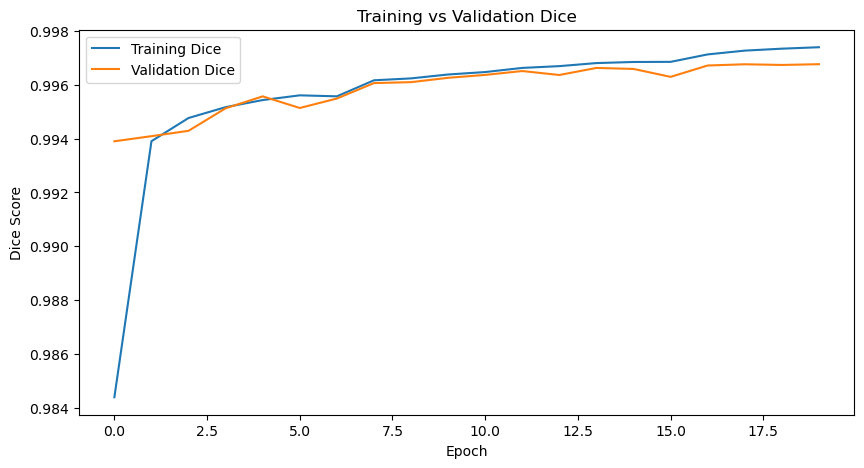

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["dice_score"],
    label="Training Dice"
)

plt.plot(
    history.history["val_dice_score"],
    label="Validation Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")

plt.title("Training vs Validation Dice")

plt.legend()

plt.show()

In [25]:
index = 10

image = X_val[index]

prediction = model.predict(
    np.expand_dims(image, axis=0),
    verbose=0
)[0]

predicted_mask = (
    prediction > 0.5
).astype(np.float32)

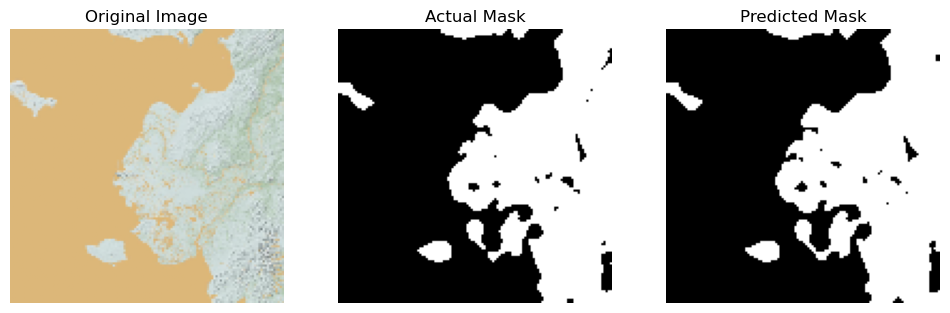

In [26]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)

plt.imshow(image)

plt.title("Original Image")

plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(
    Y_val[index].squeeze(),
    cmap="gray"
)

plt.title("Actual Mask")

plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(
    predicted_mask.squeeze(),
    cmap="gray"
)

plt.title("Predicted Mask")

plt.axis("off")


plt.show()

In [27]:
from sklearn.metrics import jaccard_score

# Predict masks for the entire validation set
Y_pred = model.predict(X_val, batch_size=4, verbose=1)

# Convert probabilities to binary masks
Y_pred_binary = (Y_pred > 0.5).astype(np.float32)

# Flatten
y_true = Y_val.flatten()
y_pred = Y_pred_binary.flatten()

# Calculate IoU
iou = jaccard_score(y_true, y_pred)

print("Validation IoU:", iou)
print("Validation Dice:", dice_score(Y_val, Y_pred_binary).numpy())

250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step
Validation IoU: 0.9939412364954349
Validation Dice: 0.9969614


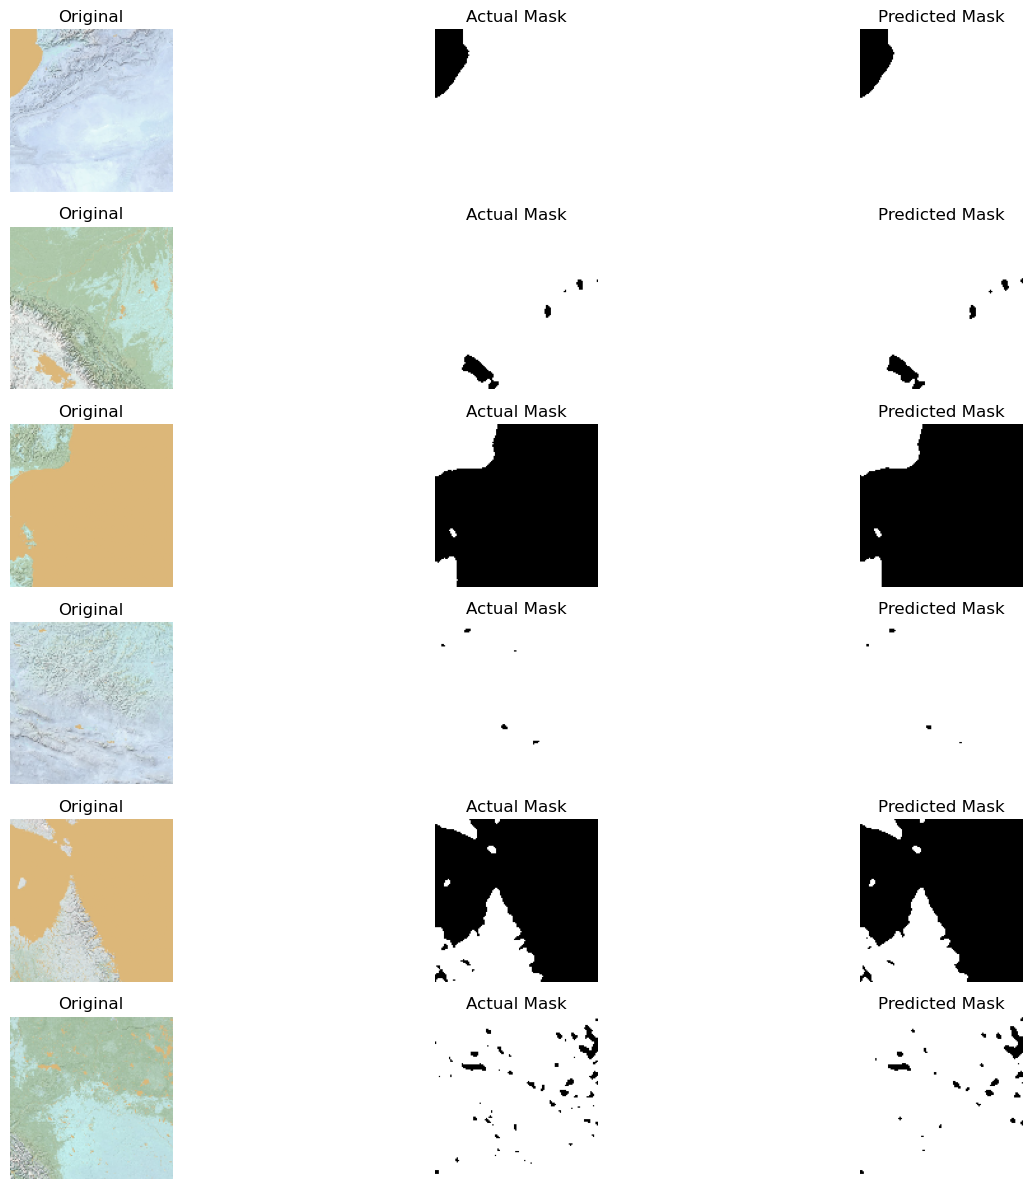

In [28]:
import random

plt.figure(figsize=(15, 12))

for i in range(6):
    index = random.randint(0, len(X_val) - 1)

    image = X_val[index]
    actual = Y_val[index]

    prediction = model.predict(
        np.expand_dims(image, axis=0),
        verbose=0
    )[0]

    predicted = (prediction > 0.5).astype(np.float32)

    plt.subplot(6, 3, i*3 + 1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(6, 3, i*3 + 2)
    plt.imshow(actual.squeeze(), cmap="gray")
    plt.title("Actual Mask")
    plt.axis("off")

    plt.subplot(6, 3, i*3 + 3)
    plt.imshow(predicted.squeeze(), cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()